In [14]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

In [ ]:
# === CONFIG ===
PR = 40
base_path = f"/data92/PeterChang/Dycore_data/PR{PR}"
u_file = f"{base_path}/u/PR{PR}_500_20000day_u_6hourly.h5"
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx"
os.makedirs(save_dir, exist_ok=True)

# === Load u ===
with h5py.File(u_file, "r") as ds:
    u = np.asarray(ds["u"][:])  # (time, lev, lat, lon)

# === EOF & PC1 Calculation ===
def Cal_EOF_PC_for_barotropic(input_data):
    import sys
    sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
    from EOF import EOF
    lat_weight = np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))
    input_data_weighted = input_data * lat_weight[np.newaxis, :]
    n_component = min(input_data.shape[0], input_data.shape[1])
    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    eof_instance.get()
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]
    PC1_norm = PC1 / PC1.std()
    EOF1_norm = EOF1 * PC1.std()
    return EOF1_norm, PC1_norm

ubar = u[:, :, 32:, :].mean(axis=(1, 3))  # (time, lat)
EOF1, PC1 = Cal_EOF_PC_for_barotropic(ubar)
plt.figure()
plt.plot(EOF1)
# PC1 
# PR0: No
# PR10: *= -1 
# PR20: *= -1 
# PR30: No
# PR40: *= -1
# PR50: No

# === Manual Sign Correction ===
if PR in [10, 20, 40]:
    PC1 *= -1
    EOF1 *= -1

# === Get ±1σ Time Indices ===
PC1_std, PC1_mean = PC1.std(), PC1.mean()
time_idx_pos = np.where(PC1 > PC1_mean + PC1_std)[0]
time_idx_neg = np.where(PC1 < PC1_mean - PC1_std)[0]

In [ ]:
# === Save indices ===
# with h5py.File(f"{save_dir}/PC1_positive_1std_PR{PR}.h5", 'w') as f:
#     f.create_dataset("time_idx_pos", data=time_idx_pos)
# with h5py.File(f"{save_dir}/PC1_negative_1std_PR{PR}.h5", 'w') as f:
#     f.create_dataset("time_idx_neg", data=time_idx_neg)

# === Plot PC1 & Extremes ===
def plot_PC1_extremes(PC1, pos_idx, neg_idx, PR):
    days = np.arange(len(PC1))
    plt.figure(figsize=(12, 6))
    plt.plot(days, PC1, label="PC1")
    plt.scatter(days[pos_idx], PC1[pos_idx], color="red", label="+1σ")
    plt.scatter(days[neg_idx], PC1[neg_idx], color="green", label="−1σ")
    plt.title(f"PC1 and ±1σ Extremes — PR{PR}")
    plt.xlabel("Time (6-hourly steps)")
    plt.ylabel("PC1")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_PC1_extremes(PC1, time_idx_pos, time_idx_neg, PR)

# Calcualte u dot PC1 to get EOF1_2D

In [27]:
def plot_contourf_near0_fixcolorbar_EOF(X, Y ,var_near0, axs, cbar_lim, shading_levels = 11, least_levels = 4, near0white = True, my_cmap = 'coolwarm'):
    from matplotlib.colors import ListedColormap
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm
    #####
    import matplotlib.colors as colors
    # a, antialiased = 0.6, True
#     a, antialiased = 0.7, True
    a, antialiased = 0.9, True
    # a, antialiased = 1, False
    
    my_cmap = plt.colormaps[my_cmap]  
    
    # create random data with cbar_lim
    rngdata = np.random.uniform(low=cbar_lim[0], high=cbar_lim[1], size=(len(Y),len(X)))
    
    # make sure the min and Max value are included
    rngdata[0,0] = cbar_lim[0]
    rngdata[-1,-1] = cbar_lim[1]

    # get contour levels with random data
    cs = axs.contourf(X, Y, rngdata, levels = 11, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels_rng = cs.levels.copy()
    plt.gca().clear()
    
    cs = axs.contourf(X, Y, var_near0, levels = auto_levels_rng, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels2 = cs.levels.copy()
    # cbar = add_colorbar(cs)#plt.colorbar()
    #plt.show()

    if ~((np.min(auto_levels2) >= 0) | (np.max(auto_levels2) <= 0)):
        plt.gca().clear()
        
        try:
            cbar.remove()
        except:
            pass
        
        # check levels of both ends
        # if either end has contour levels less than 'least_levels', create custom levels
        if ((len(np.where(auto_levels2 > 0)[0]) < least_levels) | (len(np.where(auto_levels2 < 0)[0]) < least_levels)):
            cs = plt.contourf(X,Y,var_near0, norm=TwoSlopeNorm(0), levels = np.linspace(auto_levels_rng.min(), auto_levels_rng.max(), 100))
            auto_levels1 = cs.levels.copy()
        #     plt.colorbar()
        #     plt.show()
            plt.gca().clear()
            if (len(np.where(auto_levels2 > 0)[0]) > len(np.where(auto_levels2 < 0)[0])):
                   custom_levels = np.concatenate((np.linspace(np.min(auto_levels1), 0, least_levels+1), 
                                    auto_levels2[auto_levels2 > 0]))

            else:
                   custom_levels = np.concatenate((auto_levels2[auto_levels2 < 0], 
                                               np.linspace(0,np.max(auto_levels1),least_levels+1)))

            #custom_levels = np.unique(custom_levels)
            custom_levels_bar = custom_levels
        else:

            custom_levels = auto_levels2
            custom_levels_bar = custom_levels

        # create white shading around 0
        if near0white:
            custom_lower = custom_levels[custom_levels < 0]
            dlevel_lower = custom_lower[1] - custom_lower[0]
            custom_lower_near0 = np.concatenate((custom_lower, [0 - dlevel_lower/5]))

            custom_upper = custom_levels[custom_levels > 0]
            dlevel_upper = custom_upper[1] - custom_upper[0]
            custom_upper_near0 = np.concatenate(([dlevel_upper/5 - 0] ,custom_upper))

            custom_levels_near0 = np.concatenate((custom_lower_near0, [0], custom_upper_near0))

            mycmap_lower_near0 = my_cmap(np.linspace(0, 0.5, len(custom_levels_near0[custom_levels_near0 < 0])))
            mycmap_upper_near0 = my_cmap(np.linspace(0.5, 1, len(custom_levels_near0[custom_levels_near0 >= 0])))[1:]
            all_colors = np.vstack((mycmap_lower_near0, mycmap_upper_near0))

            all_colors[np.where(custom_levels_near0 == 0)[0]] = [1, 1, 1, 1] # set to white
            all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [1, 1, 1, 1]
            
#             all_colors[np.where(custom_levels_near0 == 0)[0]] = [0.85, 0.85, 0.85, 1] # set to gray
#             all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [0.85, 0.85, 0.85, 1]

            #all_colors[:,0:3] *= a


            mycmap_near0 = colors.LinearSegmentedColormap.from_list('mycmap_near0', all_colors)

            custom_levels = custom_levels_near0
            mycmap = mycmap_near0
        else:
            mycmap = my_cmap


        norm = colors.BoundaryNorm(boundaries=custom_levels, ncolors=256)

        cs = axs.contourf(X, Y, var_near0, levels = custom_levels, cmap=mycmap, norm=norm, alpha = a, antialiased = antialiased)
        cbar = plt.colorbar(cs, spacing="proportional")#cbar = add_colorbar(cs, aspect=8, pad_fraction=0.8)#

#         cbar.set_ticks(custom_levels_bar)
#         ticklabs = cbar.ax.get_yticklabels()
#         cbar.ax.set_yticklabels(ticklabs, fontsize=14)

        # plt.title("c) EOF1", fontsize=14)
        # plt.xlabel("Latitude")
        ax.set_ylabel("Sigma")
        ax.invert_yaxis()
        # plt.ylim([1,0])
        # plt.xlim([0,70])


        
    #####
    return custom_levels, custom_levels_bar, cs

In [26]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# --- CONFIG ---
PR = 50
base_path = f"/data92/PeterChang/Dycore_data/PR{PR}"
u_file = f"{base_path}/u/PR{PR}_500_20000day_u_6hourly.h5"

# --- Load data ---
with h5py.File(u_file, "r") as ds:
    u = np.asarray(ds["u"][:])  # shape: (time, lev, lat, lon)

# --- Latitude weighting ---
lat = np.linspace(0, 90, u.shape[2])
lat_weight = np.sqrt(np.cos(np.deg2rad(lat[32:])))  # lat from 32 to 63

# --- EOF function ---
def Cal_EOF_PC_for_barotropic(input_data: np.ndarray, lat_weight: np.ndarray):
    import sys
    sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
    from EOF import EOF
    input_weighted = input_data * lat_weight[np.newaxis, :]
    n_component = min(input_data.shape[0], input_data.shape[1])
    eof_instance = EOF((input_weighted,), n_components=n_component, field="1D")
    eof_instance.get()
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]
    PC1_norm = PC1 / PC1.std()
    EOF1_norm = EOF1 * PC1.std()
    return EOF1_norm, PC1_norm

# --- Calculate barotropic u and apply EOF ---
ubar = u[:, :, 32:, :].mean(axis=(1, 3))  # (time, lat=32)
EOF1, PC1 = Cal_EOF_PC_for_barotropic(ubar, lat_weight)

# --- Apply sign correction ---
if PR in [10, 20, 40]:
    PC1 *= -1
    EOF1 *= -1

# --- Project u onto PC1 to get EOF1 structure ---
u_reshape = u[:, :, 32:, :].mean(axis=3).reshape(ubar.shape[0], -1)
PC1_column = PC1.reshape(-1, 1)
EOF1_dot = u_reshape.T @ PC1_column / (PC1 @ PC1_column)
EOF1_dot_reshape = EOF1_dot.reshape((u.shape[1], u.shape[2] - 32))  # (level, lat=32)

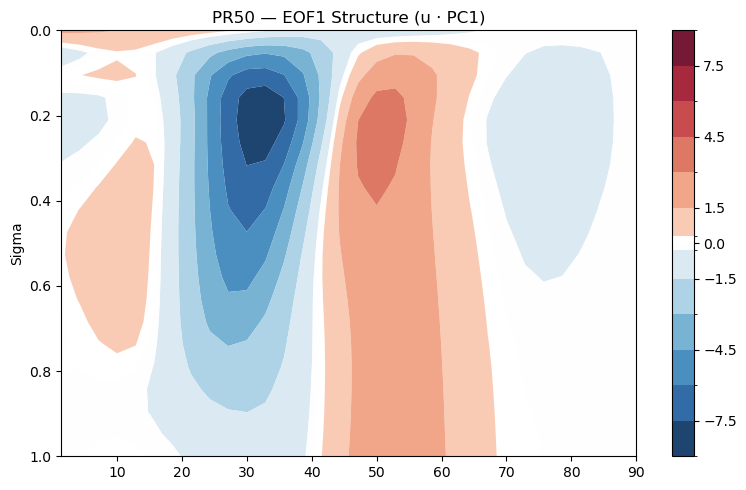

In [25]:

# --- Plot EOF1 structure ---
y = np.linspace(-90, 90, 64)
sigma = np.linspace(0, 1, 20)
fig, ax = plt.subplots(1, figsize=(8,5))
plot_contourf_near0_fixcolorbar_EOF(y[32:], sigma, EOF1_dot_reshape, ax, cbar_lim=[-9, 9], my_cmap="RdBu_r")
ax.set_title(f"PR{PR} — EOF1 Structure (u ⋅ PC1)")
plt.tight_layout()

plt.show()

# --- Save to HDF5 ---
# save_path = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_EOF1/PR{PR}_EOF1_projection_z_y.h5"
# with h5py.File(save_path, "w") as f:
#     f.create_dataset("EOF1_dot", data=EOF1_dot_reshape)
#     f.attrs["description"] = "EOF1: zonal mean u projection onto PC1"
#     f.attrs["dimensions"] = "(level, latitude>=32)"
#     f.attrs["PR"] = PR
# print(f"✅ Saved EOF1 projection to: {save_path}")